# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

Краткое описание проекта: необходимо построить модель прогнозирования оттока клиентов в Happy Beans Coffee для выявления клиентов, склонных к уходу

#### Название проекта: 

Разработка модели по прогнозированию оттока клиентов  в Happy Beans Coffee

#### Описание: 

На рынке доставки кофе высокая конкуренция, поэтому привлечение нового клиента обходится в 5–7 раз дороже, чем удержание существующего. В последние месяцы Happy Beans Coffee столкнулись с проблемой: каждый месяц сервис теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку. Из-за этого также неэффективно расходуется маркетинговый бюджет: он «работает вхолостую», не обеспечивая прироста клиентской базы

#### Тип задачи

Бинарная классификация с учителем

#### Цель модели

Предсказать вероятность того, что клиент прекратит пользоваться сервисом доставки кофе в течение следующего месяца

#### Цель исследования: 

Разработать модель машинного обучения для прогнозирования оттока клиентов сервиса доставки кофе, которая позволит службе маркетинга и клиентского сервиса своевременно применять удерживающие механики

#### Суть исследования: 

Найти закономерности в поведении клиентов, которые предшествуют их уходу, чтобы на основе этих закономерностей научиться предсказывать отток и предпринимать меры

#### Задачи исследования:

1. Подготовка исходных данных
2. Проведение исследовательского анализа данных
3. Провести предварительную обработку данных и признаков
4. Подготовить пайплайн обработки датасетов
5. Разделить выборки (обучающая, валидационная, тестовая)
6. Обучение модели
7. Валидация и тестирование модели
8. Анализ признаков и оценок
9. Выбор финального набора признаков и финальной модели
10. Подготова к продакшн-использованию

#### Исходные данные:

В качестве исходных данных используется датасет, который собран из внутренних систем компании: транзакционной базы данных, логов мобильного приложения и результатов опросов. 
Датасет содержит 27 признаков и целевую переменную, которая может принимать значение 0 - клиент остался и 1 - клиент ушел

####  Этапы исследования:

Часть 1. Изучение общей информации:

1. Изучение файлов с данными, получение общей информации, загрузка библиотек.
2. Нахождение и ликвидация пропусков
3. Анализ признаков на предмет их значимости, выбросов в данных

Часть 2. Подготовка данных:

1. Приведение данных к нужным типам.
2. Нахождение и исправление аномалий и ошибок.
3. Подготовка и разделение выборок

Часть 3. Обучение базовой модели

1. Построение dummy модели
2. Построение модели на основе датасета с использованием кросс-валидации
3. Оценка и анализ полученной модели на основе метрик и коэффициентов

Часть 4. Доработка модели

1. Анализ признаков и их трансформация
2. Удаление не значимых признаков
3. Подготовка пайплайна для финальной модели
4. Подбор гиперпараметров

Часть 5. Финальная модель

1. Обучение финальной модели на модифицированном датасете
2. Оценка финальной модели
3. Подготовка отчета

Часть 6. Подготовка результатов работы для дальнейшего использования

1. Сохранение и выгрузка финальной модели
2. Выгрузка в репозиторий
3. Подготовка и выгрузка версий библиотек и зависимостей
4. Проверка работоспособности загруженной модели

# План работы

## Этап 1. Подготовка среды и библиотек

In [1]:
# Импортируем нужные библиотеки
import joblib
import phik
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score, recall_score, average_precision_score, get_scorer_names


In [2]:
# Зафиксируем библиотеки в requirements.txt (ссылка на сам файл - в конце проекта)

!pip freeze > requirements.txt
print("Файл requirements.txt создан!")

Файл requirements.txt создан!


In [3]:
# Импортируем датасет
df = pd.read_csv('datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

In [4]:
# Зафиксируем значения статических переменных

RANDOM_STATE = 42
N_FOLDS = 5

## Этап 2. Первичный анализ данных

In [5]:
# Запросим данные по полученному датасету

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [6]:
# Запросим статистическое описание данных для первичного выявления аномалий
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


Исходя из полученных данных, 50% клиентов сделали заказ за последние 3 дня. Однако, присутствуют клиенты, которые не заказывали более месяца (до 40 дней). Есть клиенты, которые делали заказы практически каждый день. В стоимости заказов есть аномальные, отрицательные значения. С ними придется провести обработку. 
Примерно 25% клиентов постоянно пользуются скидками, однако есть те, кто не получал промо оффера несколько месяцев. Возможно, тут есть поле для работы. Часть пользователей сталкиваются с ошибками и сбоями в работе приложения, 50% клиентов получают сбой 1 раз в месяц, что может также влиять на лояльность клиентов. 

Целевая переменная находится в дисбалансе: среднее значение по выборке 0.06, более детальные цифры ниже по исследованию

In [7]:
# Выведем первые строки датасета
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Датасет содержит данные о более чем 10 000 пользователях: частоте и стоимости их заказов, вкусовых предпочтения, оценках заказов, работе приложения. Из постановки задачи известно, что скорость ухода пользователей - примерно 10% в месяц, большинство пользователей остаются, потому данные не сбалансированы

In [8]:
# Проверим исходные данные на наличие полных дубликатов
df.duplicated().sum().item()

0

Целевая переменная -  churn (0 - пользователь остался, 1 - пользователь перестал пользоваться сервисом). 
Ее значения сдвинуты к 0 (говорит о том, что большинство пользователей остаются). Посмотрим более детально распределение

In [9]:
# Найдем распределение клиентов по целевой переменной
df['churn'].value_counts()

churn
0    9821
1     629
Name: count, dtype: int64

Таким образом, подтверждается, что большинство клиентов остаются, потому датасет не сбалансирован. 
Это потребуется учесть при выборе оценки моделей. Accuracy не подойдет, но можно использовать Precision и Recall или их сочетание - метрику F1 и PR-AUC

Признаки можно разбить на несколько категорий:

1. Идентификатор пользователя (user_id)
2. Статистика по заказам (days_since_last_order, order_frequency_month, order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, total_spent_last_week, discount_usage_rate)
3. Данные по вкусовым предпочтениям клиентов (last_coffee_type, preferred_roast, milk_preference, seasonal_menu_tried, coffee_bean_origin, coffee_preference_change)
4. Статистика по использованию приложения (app_opens_per_week, notifications_enabled, app_crashes_last_month, phone_type)
5. Оценки пользователя (review_rating_last_10, review_rating_last_1)
6. Дополнительные параметры (last_drink_size, subscription_status, seasons, days_since_last_promo, geo_id)

Проанализировав по смыслу, предполагаю, что уход из сервиса не зависит от признаков: Идентификатор пользователя, сорта кофе, предпочтений по обжарке, размера приобретаемой порции, предпочтений по молоку, геопозиции, типа телефона, включены ли уведомления на телефоне. Данные признаки предлагается удалить

Также предлагается удалить данные по средней стоимости заказа - оставив медианную, затратах за неделю - оставив затраты за месяц, и оценку последнего заказа - оставив среднюю оценку последних 10 заказов. Эти данные похожи, и могут привести к "размазыванию" коэффициентов

In [10]:
# Составим список колонок для удаления в отдельной переменной. Это позволит удобно вносить изменения, если потребуется. Также создадим копию дата сета и будем работать с ним.

df_copy = df.copy()

columns_to_delete = ["user_id",
                    "avg_order_value",
                    "total_spent_last_week",
                    "preferred_roast", 
                    "milk_preference", 
                    "coffee_bean_origin",
                    "notifications_enabled",
                    "phone_type", 
                    "last_drink_size",
                    "review_rating_last_1",
                    "seasons",
                    "geo_location"]

# Удалим нужные столбцы из копии датафрейма

df_copy = df_copy.drop(columns=columns_to_delete)

Практически по всем колонкам есть пропущенные значения. Так как данные были собраны из различных источников, часть пропусков можно объяснить тем, что не по всем пользователям данные пересекаются.
Пропуски в статистике по заказам могут говорить о том, что часть пользователей зарегистрировалась, но не делала заказы. Пропуски в оценках могут говорить о том, что не все пользователи захотели проставить оценку заказам. Пропуски в вкусовых предпочтениях - не все пользователи выбрали какой либо тип кофе, обжарки, либо же причина - не все зарегистрированные пользователи делали заказы.

Пропуски в стоимостных колонках можно заполнить средним значением, пропуски в оценках заказов также можно заполнить средним значением, пропуски в категориальных данных заполним самым часто встречающимся значением.

В предыдущих пунктах уже указан список категориальных признаков, которые можно удалить. Это: last_coffee_type, preferred_roast, milk_preference, coffee_bean_origin, phone_type, last_drink_size, seasons, geo_id
Для кодирования можно использовать признаки: subscription_status - чтобы выяснить, как наличие подписки влияет на вероятность ухода клиента с сервиса, и last_coffee_type - чтобы выяснить, возможно последний заказ какого либо вида кофе приводит к уходу клиентов.
Выведем уникальные значения категорий в данных полях

In [11]:
df_copy['last_coffee_type'].unique()

<StringArray>
['blend', 'arabica', 'robusta', nan]
Length: 4, dtype: str

In [12]:
df_copy['subscription_status'].unique()

<StringArray>
['pro', 'none', 'premium', 'basic', nan]
Length: 5, dtype: str

In [13]:
# Выведем данные основных статистических параметров по датафрейму после удаления столбцов

df_copy.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,median_order_value,total_spent_last_month,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,review_rating_last_10,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9619.000000,10156.000000,10053.000000,9461.000000,9554.000000,9757.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,452.651500,1946.132979,0.284446,0.701194,11.330895,4.206709,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,258.657571,2370.619590,0.158735,0.457759,14.528887,0.782212,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-10.353340,-43.716463,0.002162,0.000000,0.000000,1.415526,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,262.908598,629.680382,0.159884,0.000000,6.313628,3.675543,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,406.456818,1300.409757,0.264583,1.000000,9.228383,4.203555,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,590.418070,2481.650495,0.387056,1.000000,12.726649,4.717292,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,2189.101644,79298.849570,0.887301,1.000000,224.587876,7.384425,7.000000,140.000000,1.000000,1.000000


Аномальные значения есть в столбцах: order_frequency_week - отрицательная частота заказов, total_spent_last_month - отрицательная сумма заказов за месяц, median_order_value - отрицательная медианная стоимость. 
Для обработки этих выборосов - предлагается удалить данные строки, так как данные в них - не соответствуют реальному смыслу данных полей.

In [14]:
df_copy_filtered = df_copy.loc[(df_copy["order_frequency_week"] >= 0) 
    & (df_copy["total_spent_last_month"] >= 0) 
    & (df_copy["median_order_value"] >= 0)]

In [15]:
# Проверяем 

df_copy_filtered.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,median_order_value,total_spent_last_month,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,review_rating_last_10,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,8103.000000,8391.000000,8916.000000,8916.000000,8916.000000,8579.000000,8077.000000,8133.000000,8321.000000,8310.000000,8269.000000,8385.000000,8916.000000
mean,4.418117,4.036166,0.934741,452.907036,1966.841944,0.284335,0.703108,11.446261,4.212721,1.007581,14.563672,0.194514,0.059219
std,4.871281,2.800851,0.651372,257.898876,2407.603470,0.158066,0.456917,15.044553,0.780117,1.002375,15.337320,0.395850,0.236048
min,0.000000,0.027092,0.000787,2.088046,5.244094,0.002162,0.000000,0.000000,1.415526,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.978043,0.453454,263.975527,644.836670,0.160812,0.000000,6.351766,3.690634,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.400145,0.787243,406.978926,1313.739499,0.265039,1.000000,9.251273,4.210400,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.441300,1.260701,590.345274,2497.663683,0.386602,1.000000,12.742465,4.715670,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,2189.101644,79298.849570,0.887301,1.000000,224.587876,7.384425,6.000000,140.000000,1.000000,1.000000


In [16]:
df_copy_filtered.info()

<class 'pandas.DataFrame'>
Index: 8916 entries, 1 to 10449
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8103 non-null   float64
 1   order_frequency_month     8391 non-null   float64
 2   order_frequency_week      8916 non-null   float64
 3   median_order_value        8916 non-null   float64
 4   total_spent_last_month    8916 non-null   float64
 5   discount_usage_rate       8579 non-null   float64
 6   last_coffee_type          8701 non-null   str    
 7   seasonal_menu_tried       8077 non-null   float64
 8   subscription_status       8123 non-null   str    
 9   app_opens_per_week        8133 non-null   float64
 10  review_rating_last_10     8321 non-null   float64
 11  app_crashes_last_month    8310 non-null   float64
 12  days_since_last_promo     8269 non-null   float64
 13  coffee_preference_change  8385 non-null   float64
 14  churn                  

In [17]:
 #Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Напишем функции визуализации для численных непрерывных признаков
def plot_numerical_churn(df, column, target_col='churn'):

    plt.figure(figsize=(12, 4))
    
    # График 1
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=column, hue=target_col, kde=True, 
                 palette=['green', 'red'], alpha=0.6)
    plt.title(f'{column}: Ушедшие (Red) vs Оставшиеся (Green)')
    
    # График 2
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x=target_col, y=column, 
                palette=['green', 'red'])
    plt.title(f'{column}: Распределение по группам')
    
    plt.tight_layout()
    plt.show()

In [18]:
# Функция для дискретных признаков

def plot_discrete_churn(df, column, target_col='churn'):
    
    plt.figure(figsize=(10, 6))
    
    # Сортируем по проценту оттока для лучшего понимания
    churn_order = df.groupby(column)[target_col].mean().sort_values().index
    
    ax = sns.countplot(data=df, x=column, hue=target_col,
                       order=churn_order,
                       palette=['green', 'red'])
    
    plt.title(f'Распределение {column} по оттоку')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.legend(title='Churn', labels=['Остался', 'Ушел'])
    
    # Добавляем подписи значений
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x() + p.get_width()/2., height + 0.5,
                   int(height), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()


In [19]:
# Основная функция для разделения колонок 

def plot_all_distributions(df, target_col='churn'):
    
    # Явно указываем дискретные признаки
    discrete_cols = ['app_crashes_last_month', 
                     'coffee_preference_change', 'seasonal_menu_tried']
    
    # Числовые признаки (непрерывные)
    potential_num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Убираем дискретные из числовых и целевую переменную
    num_cols = [col for col in potential_num_cols 
                if col not in discrete_cols and col != target_col]
    
    # Категориальные признаки (object, category)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Добавляем булевы признаки в дискретные
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    discrete_cols.extend(bool_cols)
    
    # Убираем целевую переменную из дискретных
    if target_col in discrete_cols:
        discrete_cols.remove(target_col)
    
    # Анализируем непрерывные числовые признаки
    if num_cols:
        print("\n" + "="*50)
        print("Числовые признаки")
        print("="*50)
        for col in num_cols:
            print(f"\nПризнак: {col}")
            plot_numerical_churn(df, col, target_col)
    
    # Анализируем дискретные признаки
    if discrete_cols:
        print("\n" + "="*50)
        print("Дискретные признаки")
        print("="*50)
        for col in discrete_cols:
            print(f"\nПризнак: {col}")
            print(f"Уникальные значения: {sorted(df[col].unique())}")
            plot_discrete_churn(df, col, target_col)
    
    # Анализируем категориальные признаки
    if cat_cols:
        print("\n" + "="*50)
        print("Категориальные признаки")
        print("="*50)
        for col in cat_cols:
            if col != target_col:  # Убираем целевую переменную
                print(f"\nПризнак: {col}")
                print(f"Уникальные значения: {df[col].unique()}")
                plot_discrete_churn(df, col, target_col)  # Используем ту же функцию



Числовые признаки

Признак: days_since_last_order


/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/3190661810.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,


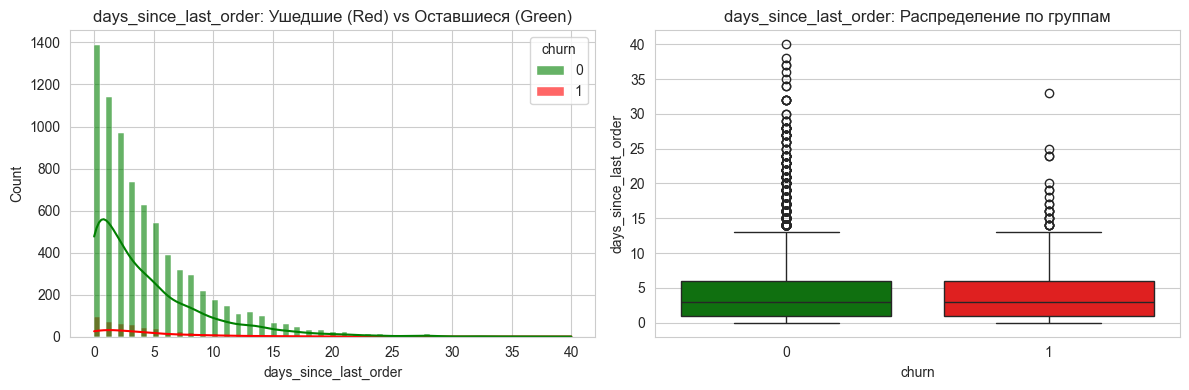


Признак: order_frequency_month


/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,


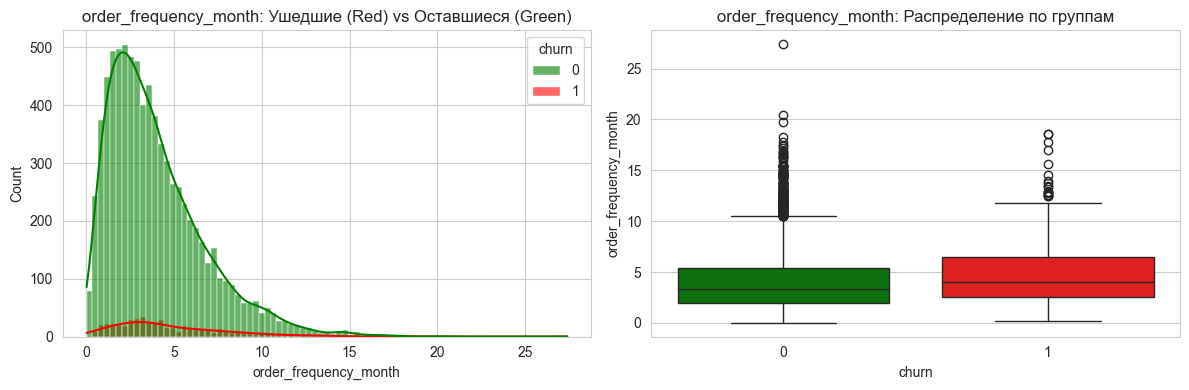


Признак: order_frequency_week


/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,


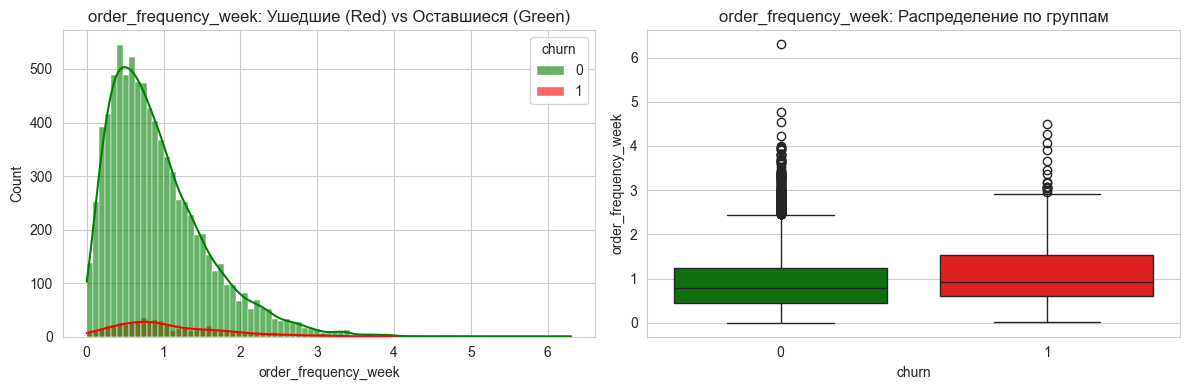


Признак: median_order_value


/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,


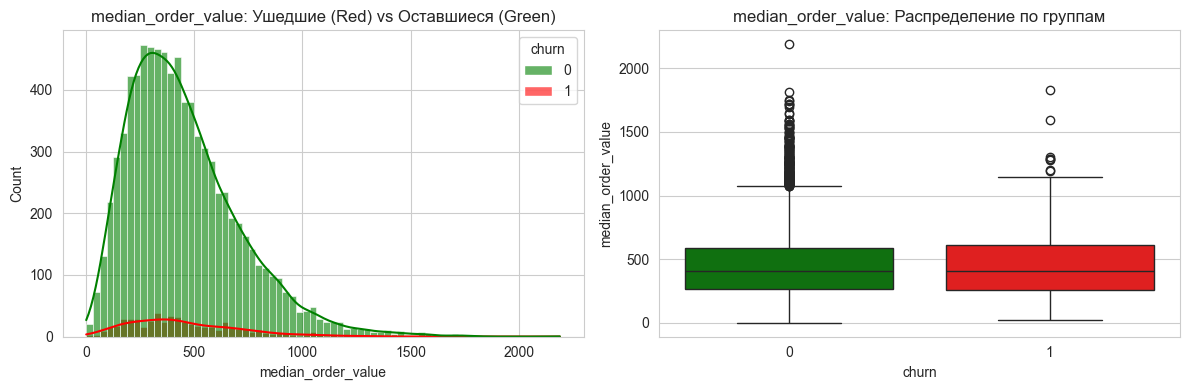


Признак: total_spent_last_month


/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,


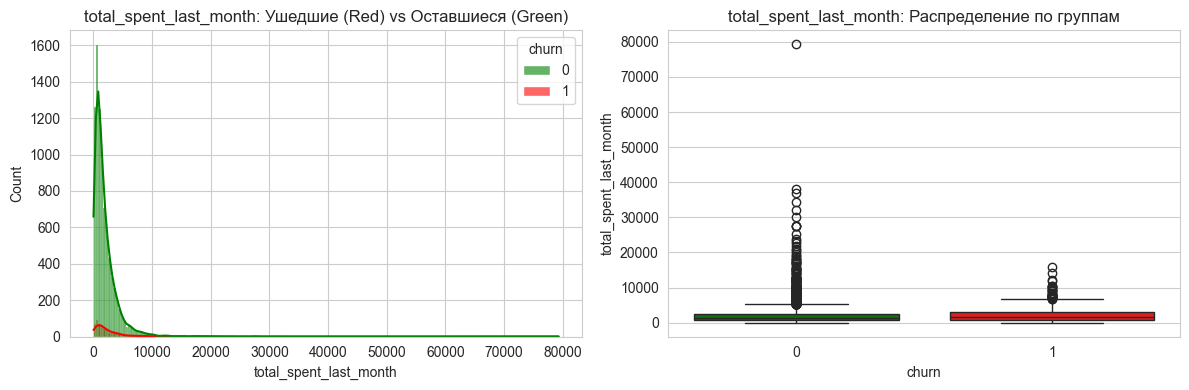


Признак: discount_usage_rate


/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,


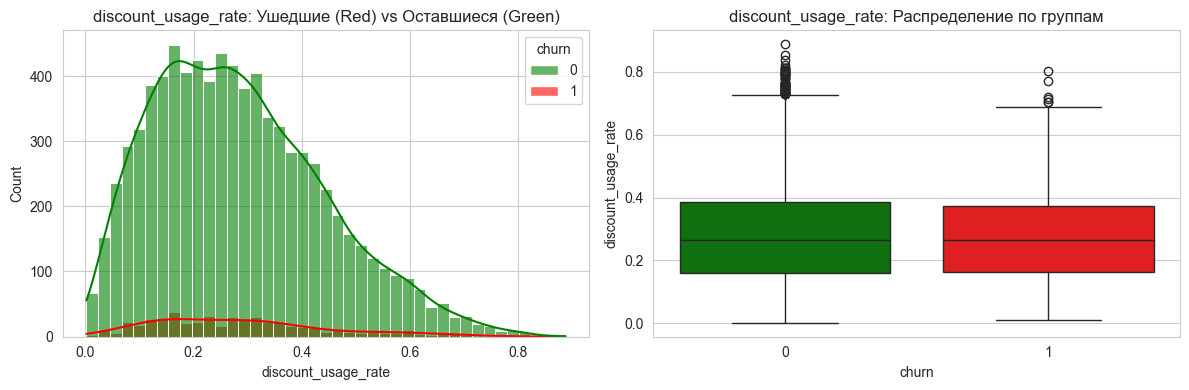


Признак: app_opens_per_week


/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,


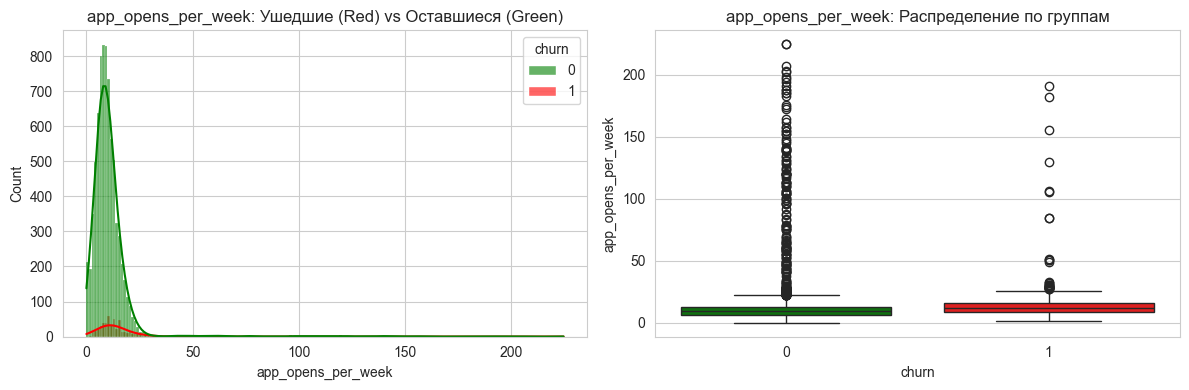

/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,



Признак: review_rating_last_10


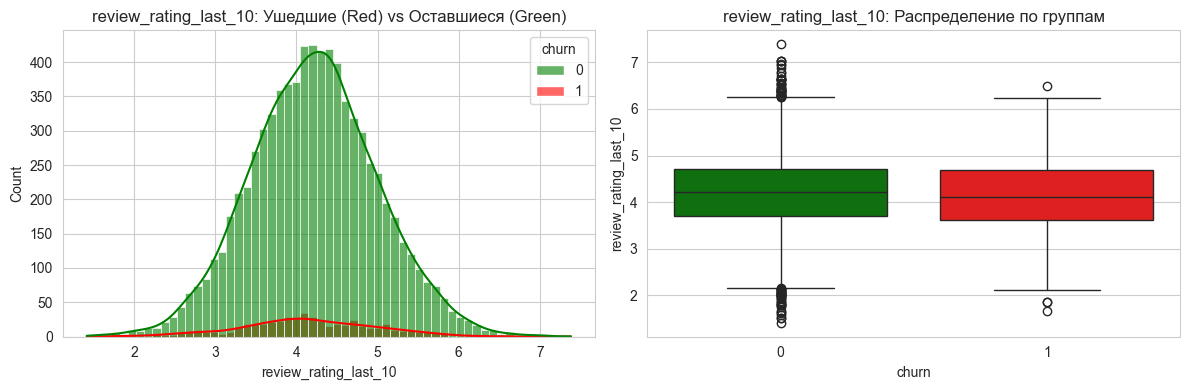


Признак: days_since_last_promo


/var/folders/cp/6xggxd6j7355pddqy4fzbk2w0000gn/T/ipykernel_39048/129611798.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=column,


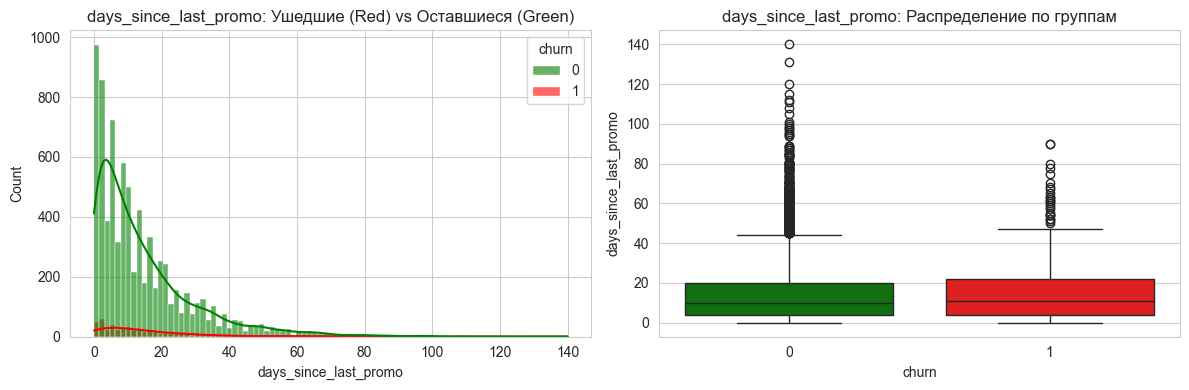


Дискретные признаки

Признак: app_crashes_last_month
Уникальные значения: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(nan), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]


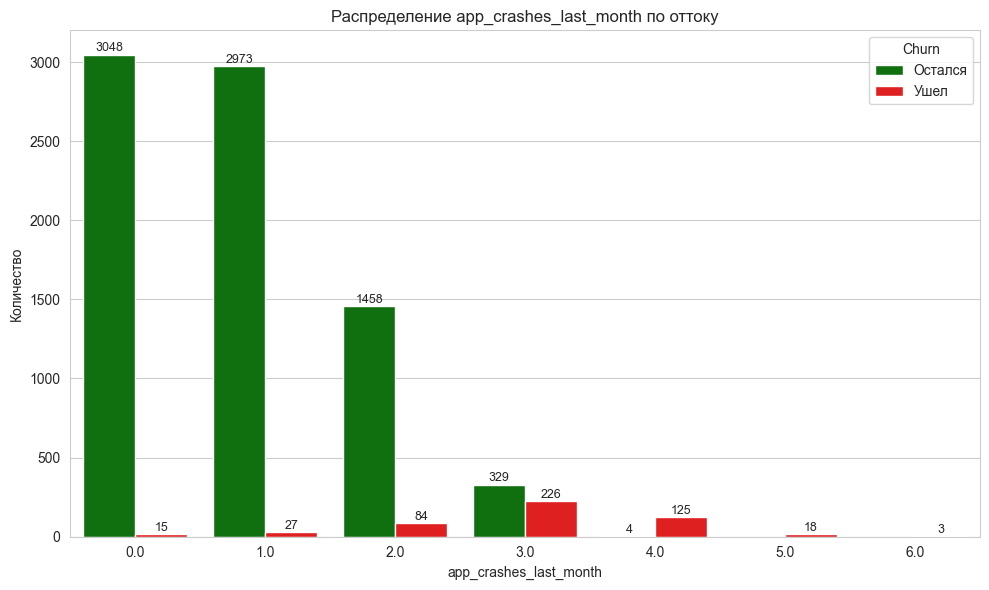


Признак: coffee_preference_change
Уникальные значения: [np.float64(0.0), np.float64(1.0), np.float64(nan)]


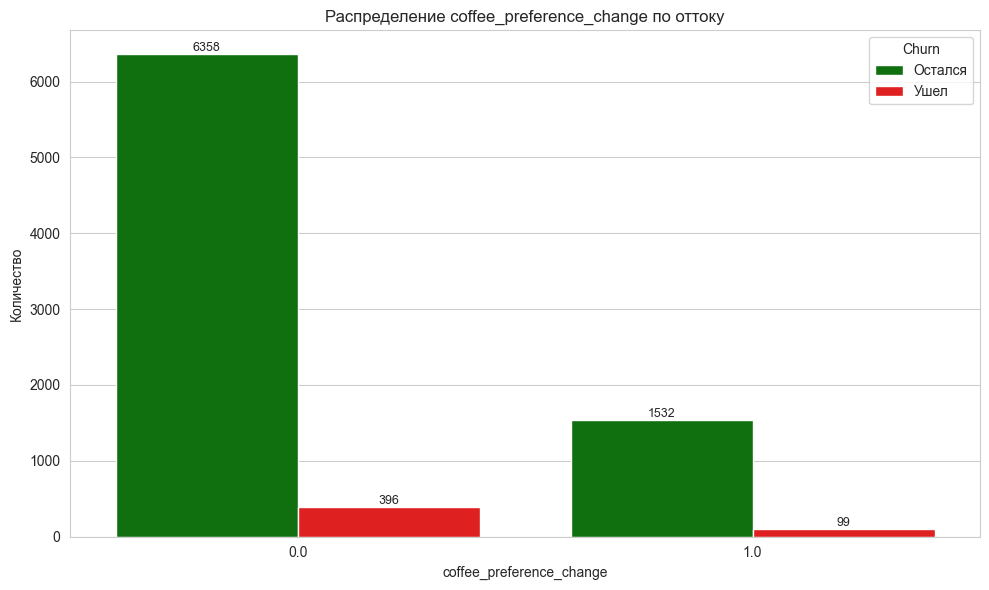


Признак: seasonal_menu_tried
Уникальные значения: [np.float64(0.0), np.float64(nan), np.float64(1.0)]


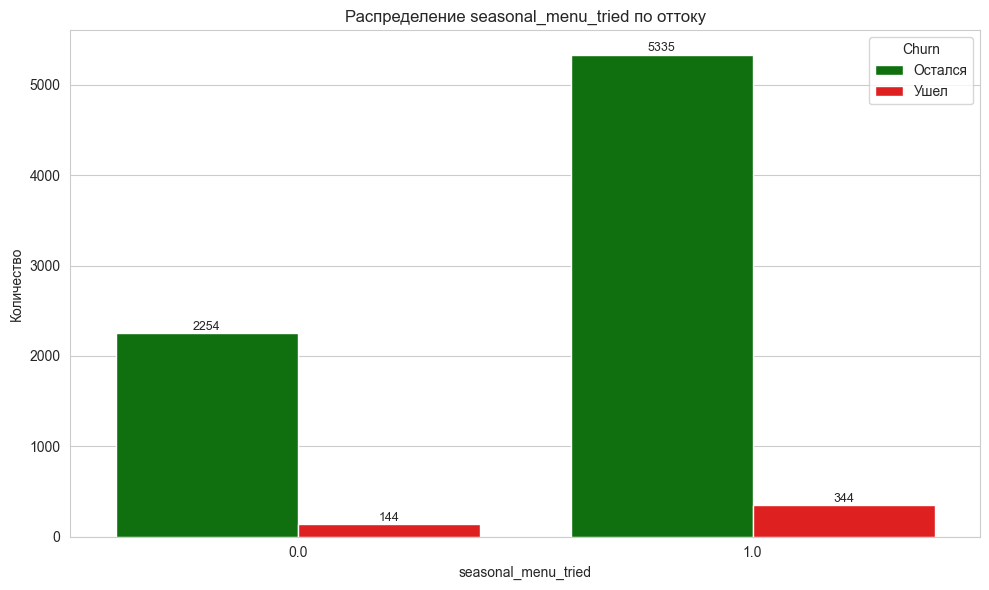


Категориальные признаки

Признак: last_coffee_type
Уникальные значения: <StringArray>
['arabica', 'robusta', nan, 'blend']
Length: 4, dtype: str


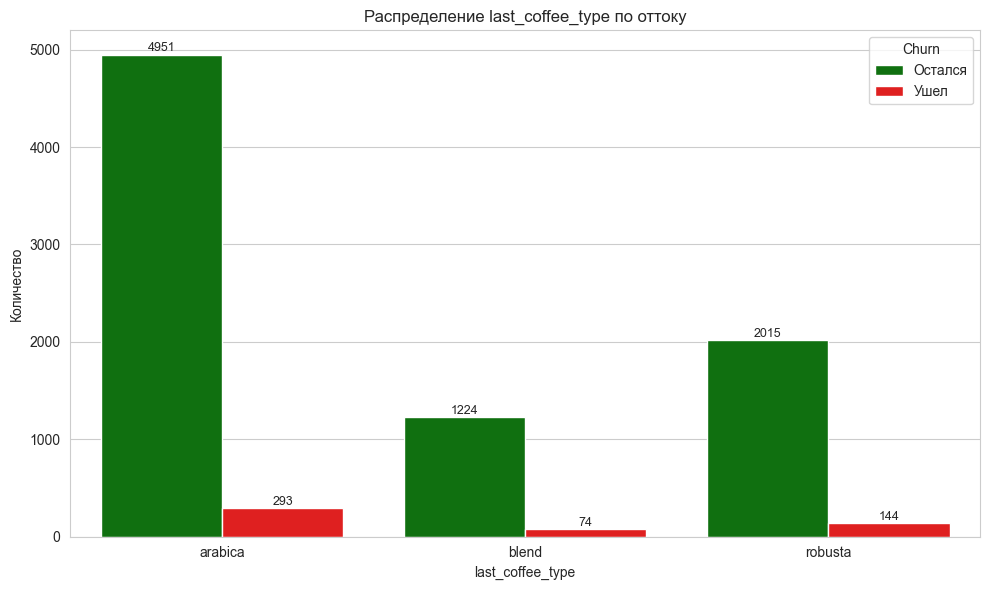


Признак: subscription_status
Уникальные значения: <StringArray>
['none', 'premium', 'pro', 'basic', nan]
Length: 5, dtype: str


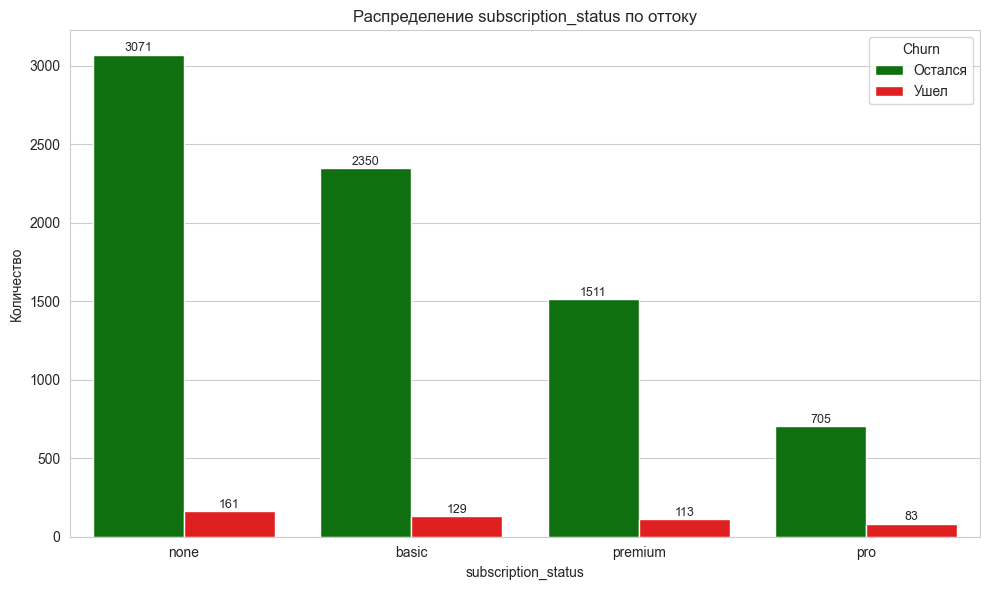

In [20]:
# Вызываем итоговую функцию и передаем ей наш датасет

plot_all_distributions(df_copy_filtered, target_col='churn')

Из полученной визуализации можно сделать выводы:

1. Клиент, который длительное время не делал заказ - уходит чаще
2. Клиент, который сталкивается с крашами и ошибками более 1 раза - уходит в несколько раз чаще, чем те, кто не сталкивался
3. Изменение типа кофе - не влияет на уход клиентов
4. Клиенты, которые приобретают премиум подписки - уходят реже, чем те, кто не покупают подписки
5. Клиенты, которые делают более дорогие заказы - чаще остаются

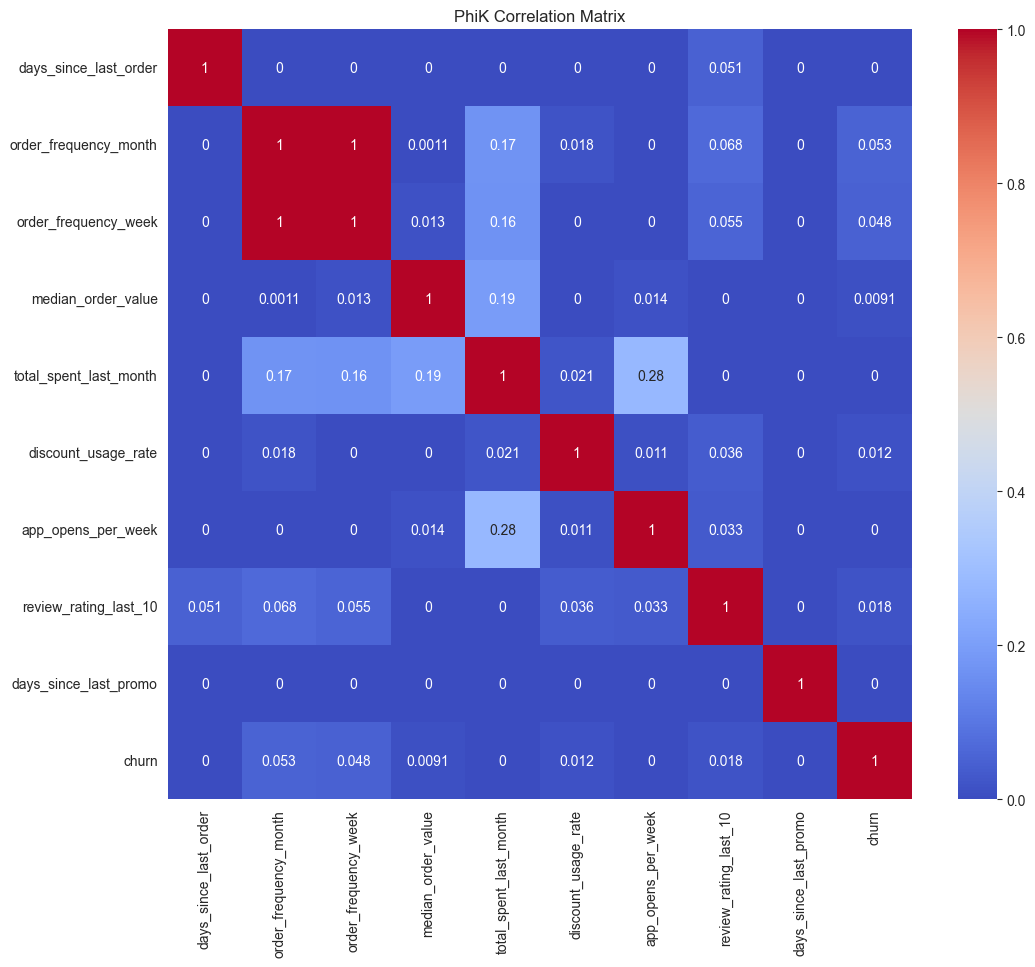

In [21]:
# Посчитаем матрицу корелляции между численными признаками и визуализируем ее
num_cols = [
    "days_since_last_order",
    "order_frequency_month",
    "order_frequency_week",
    "median_order_value",
    "total_spent_last_month",
    "discount_usage_rate", 
    "app_opens_per_week",
    "review_rating_last_10",
    "days_since_last_promo"
]

cols_to_show = num_cols + ['churn']

corr_matrix = df_copy_filtered.phik_matrix(bins=5, interval_cols=num_cols)

corr_matrix_filtered = corr_matrix.loc[cols_to_show, cols_to_show]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_filtered, annot=True, cmap='coolwarm')
plt.title('PhiK Correlation Matrix')
plt.show()

Из данной визуализации можно сделать вывод, что признаки "order_frequency_month" и "order_frequency_week" близки к абсолютной корелляции и можно оставить один из них, чтобы избежать мультиколлинеарности

In [22]:
# Удалим колонку "order_frequency_week"

df_copy_filtered = df_copy_filtered.drop(columns="order_frequency_week")

In [23]:
df_copy_filtered.info()

<class 'pandas.DataFrame'>
Index: 8916 entries, 1 to 10449
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8103 non-null   float64
 1   order_frequency_month     8391 non-null   float64
 2   median_order_value        8916 non-null   float64
 3   total_spent_last_month    8916 non-null   float64
 4   discount_usage_rate       8579 non-null   float64
 5   last_coffee_type          8701 non-null   str    
 6   seasonal_menu_tried       8077 non-null   float64
 7   subscription_status       8123 non-null   str    
 8   app_opens_per_week        8133 non-null   float64
 9   review_rating_last_10     8321 non-null   float64
 10  app_crashes_last_month    8310 non-null   float64
 11  days_since_last_promo     8269 non-null   float64
 12  coffee_preference_change  8385 non-null   float64
 13  churn                     8916 non-null   int64  
dtypes: float64(11), int64(1

#### По итогам анализа можно сделать следующие выводы:
1. В данных нет дубликатов
2. В данных присутствовали колонки, которые не имеют практического смысла для нашего исследования
3. В данных присутствуют выбросы и пропуски, которые будут обработаны по итогам этапа предобработки
4. В данных присутствуют колонки, которые являются мультиколлинеарными - они были удалены из датафрейма

## Этап 3. Предобработка данных

In [24]:
# Сохраним оригинальные данные по входящим признакам 

X_original = df_copy_filtered.drop(columns=["churn"]).reset_index(drop=True)

##### 1. Разделим данные в пропорции 80 к 20

In [25]:
# Разделяем входящие признаки и целевую переменную
X = X_original
y = df_copy_filtered["churn"]

In [26]:
# Разделяем на тестовую и обучающую выборки

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

##### 2. Подготовка пайплайнов для предобработки данных

In [27]:
# Ошибочные выбросы были удалены на этапе исследовательского анализа. Однако, в оставшейся выборке есть аномальные значения по полям: 
# median_order_value и total_spent_last_month. Их предлагается заполнить фиксированными значениями: median_order_value = 100 руб, total_spent_last_month = 200 руб.
# Подготовим функцию для этой операции

def fill_ejections(X):
    
    X[:, 2] = np.where(X[:, 2] < 100, 100, X[:, 2])
    X[:, 3] = np.where(X[:, 3] < 200, 200, X[:, 3])
    
    return X

In [28]:
# Разделим признаки на несколько категорий, в зависимости от предполагаемой стратегии обработки пропусков

# Заполнение средними значениями:
num_cols = ["days_since_last_order",
             "order_frequency_month",
             "median_order_value",
             "total_spent_last_month",
             "discount_usage_rate",
             "seasonal_menu_tried",
             "review_rating_last_10",
             "app_opens_per_week",
             "app_crashes_last_month",
             "days_since_last_promo"]

# Обработчики численных признаков
num_imputer = SimpleImputer(strategy='mean')
num_scaler = StandardScaler()

# Заполнение самыми частыми значениями
cat_cols = ["last_coffee_type",
            "subscription_status"]

# Обработчики категориальных признаков
# Во избежание дамми-ловушки удалим по одной категории из каждой категориальной колонки drop='first' в OneHotEncoder

cat_imputer = SimpleImputer(strategy='most_frequent')
cat_encoder = OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=False, drop='first')

In [29]:
# Создадим пайплайны заполнения пропущенных значений и масштабирование

num_pipeline = Pipeline(steps=[
                  ('impute_nums', num_imputer), 
                  ('handle_outliers', FunctionTransformer(fill_ejections, validate=False)), 
                  ('scale_nums', num_scaler)      
])

cat_pipeline = Pipeline(steps=[
                   ('impute_cats', cat_imputer), 
                   ('encode_cats', cat_encoder)      
])

# Объединим в трансформер

preprocessor = ColumnTransformer(
                   transformers=[
                       ('num_pipeline', num_pipeline, num_cols),
                       ('cat_pipeline', cat_pipeline, cat_cols)                  
    ]
)

## Этап 4. Обучение модели

In [30]:
# В качестве базовой модели выберем DummyClassifier с предсказанием наиболее частого значения

dummy_clf = DummyClassifier(strategy='most_frequent')

dummy_clf.fit(X_train_val, y_train_val)

# Предсказания Dummy модели
y_pred_dummy = dummy_clf.predict(X_test)
y_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

In [31]:
# Посчитаем метрики Dummy модели для последующего сравнения

# Метрики для класса 1 (churn = 1)
precision_dummy = precision_score(y_test, y_pred_dummy, pos_label=1, zero_division=0)
recall_dummy = recall_score(y_test, y_pred_dummy, pos_label=1, zero_division=0)
pr_auc_dummy = average_precision_score(y_test, y_proba_dummy)

print("Оценки DUMMY модели (только для класса '1'):")
print(f"Precision: {precision_dummy:.3f}")
print(f"Recall: {recall_dummy:.3f}")
print(f"PR-AUC: {pr_auc_dummy:.3f}")

Оценки DUMMY модели (только для класса '1'):
Precision: 0.000
Recall: 0.000
PR-AUC: 0.059


In [32]:
# Создадим пайплайн для модели логистической регрессии с помощью кросс-валидации. Из-за дисбаланса классов будем использовать 
# StratifiedKFold

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

base_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", LogisticRegression(random_state=RANDOM_STATE))])

# Выполним кросс валидацию на модели

res_base = cross_validate(base_pipeline, X_train_val, y_train_val, scoring=["precision", "recall", "f1", "roc_auc"], cv=cv) 

base_means = {
    'precision': res_base['test_precision'].max(),
    'recall': res_base['test_recall'].max(),
    'f1': res_base['test_f1'].max(),
    'roc_auc': res_base['test_roc_auc'].max()
} 

base_pipeline.fit(X_train_val, y_train_val)
y_train_pred_base = base_pipeline.predict(X_train_val)
y_train_proba_base = base_pipeline.predict_proba(X_train_val)[:, 1]

print("Результаты модели")
print("=" * 40)
for metric, value in base_means.items():
    print(f"{metric.upper():10s}: {value:.4f}")
print("=" * 40)

# Получим предсказания на тесте
#y_pred_base = base_pipeline.predict(X_test)

Результаты модели
PRECISION : 0.8302
RECALL    : 0.5176
F1        : 0.6377
ROC_AUC   : 0.9392


In [33]:
# Посчитаем метрики для модели логистической регрессии на обучающей выборке

precision_base = precision_score(y_train_val, y_train_pred_base, pos_label=1, zero_division=0)
recall_base = recall_score(y_train_val, y_train_pred_base, pos_label=1, zero_division=0)
pr_auc_base = average_precision_score(y_train_val, y_train_proba_base)
print("Оценки BASE модели (классификация):")

print(f"Precision: {precision_base:.3f}")
print(f"Recall: {recall_base:.3f}")
print(f"PR_AUC: {pr_auc_base:.3f}")

Оценки BASE модели (классификация):
Precision: 0.778
Recall: 0.448
PR_AUC: 0.689


По сравнению с Dummy моделью показатели оценок улучшились, метрика PR_AUC - в 13 раз лучше базовой модели. Precision и Recall у Dummy нулевые, у логистической регрессии:
согласно метрике Precision - модель угадывает 77% клиентов, которые покинут сервис, 
согласно метрике Recall - 45% всех уходящих клиентов будет определено.

## Этап 5. Создание новых признаков

In [34]:
# Заново определим переменную Х из оригинальных данных

X = X_original

1. Определим переменные, которые могут улучшить нашу модель и подготовим преобразования для них.

   Для признака total_spent_last_month скошено распределение, есть выбросы в виде больших значений. Подходящим действием будет логарифмирование данного признака

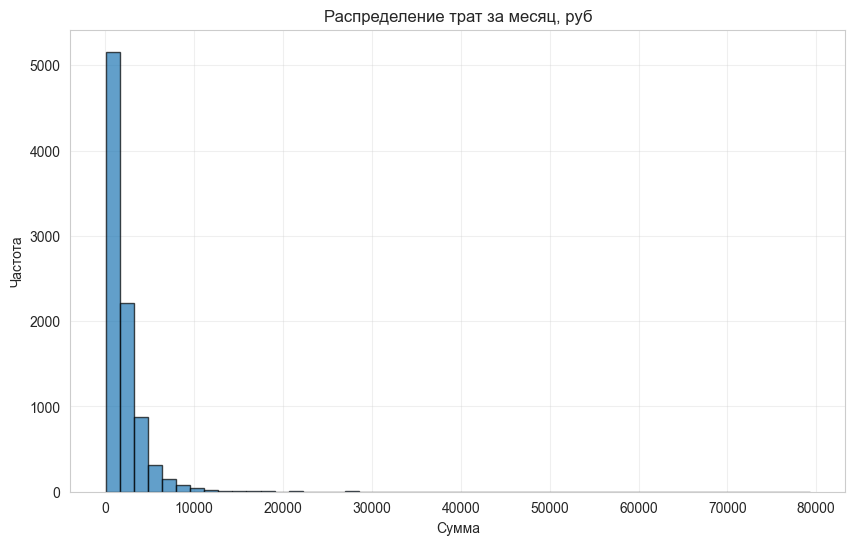

In [35]:
# Выведем гистограмму по столбцу total_spent_last_month для подтверждения вида распределения

plt.figure(figsize=(10, 6))
plt.hist(X['total_spent_last_month'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение трат за месяц, руб')
plt.xlabel('Сумма')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
# Напишем функцию для создания признаков 

def create_features(X):
    # Копируем датафрейм для создания в нем новых признаков
    
    X_enhanced = X.copy()

    # Создаем новую колонку - логарифм затрат в месяц
    X_enhanced['total_spent_last_month_log'] = np.log1p(X['total_spent_last_month'])

    # Удалим исходную колонку из расширенного датафрейма
    X_enhanced = X_enhanced.drop(columns=['total_spent_last_month'])
    
    return X_enhanced

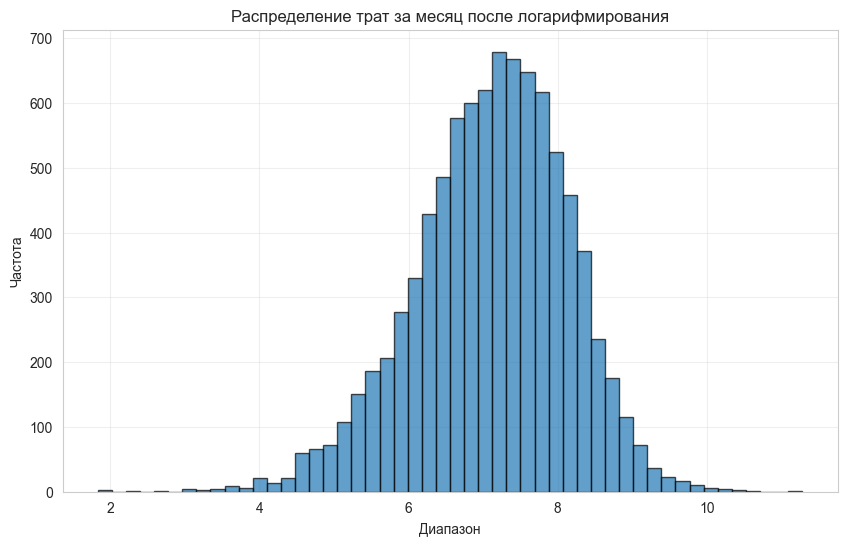

In [37]:
# Проверим, как изменилось распределение после применения функции

create_features_check = create_features(X)

plt.figure(figsize=(10, 6))
plt.hist(create_features_check['total_spent_last_month_log'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение трат за месяц после логарифмирования')
plt.xlabel('Диапазон')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()


In [38]:
# Снова разделяем на тестовую и обучающую выборки

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

In [39]:
# Применим функцию добавления признака в обучающему и тестовому датафреймам отдельно

X_train_val = create_features(X_train_val)

X_test = create_features(X_test)

In [40]:
# Обновим набор колонок для препроцессора
num_cols_enhanced = ["days_since_last_order",
                     "order_frequency_month",
                     "median_order_value",
                     "discount_usage_rate",
                     "seasonal_menu_tried",
                     "review_rating_last_10",
                     'app_crashes_last_month',
                     'app_opens_per_week',
                     "days_since_last_promo",
                     'total_spent_last_month_log']

# Доработаем обработчик числовых признаков

num_pipeline_enhanced = Pipeline(steps=[
                  ('impute_nums', num_imputer), 
                  ('handle_outliers', FunctionTransformer(fill_ejections, validate=False)), 
                  ('scale_nums', num_scaler)      
])

# Обновленный препроцессор
preprocessor_enhanced = ColumnTransformer(
                       transformers=[
                       ('num_pipeline_enhanced', num_pipeline_enhanced, num_cols_enhanced),
                       ('cat_pipeline', cat_pipeline, cat_cols)                 
    ]
)

# Создаем новый пайплайн с созданием новых признаков
enhanced_pipeline = Pipeline(
    steps=[
        ("preprocessor_enhanced", preprocessor_enhanced), 
        ("model_enhanced", LogisticRegression(random_state=RANDOM_STATE))])

In [41]:
# Выполним кросс валидацию на модели

res_enhanced = cross_validate(enhanced_pipeline, X_train_val, y_train_val, scoring=["precision", "recall", "f1", "roc_auc"], cv=cv) 

enhanced_means = {
    'precision': res_enhanced['test_precision'].max(),
    'recall': res_enhanced['test_recall'].max(),
    'f1': res_enhanced['test_f1'].max(),
    'roc_auc': res_enhanced['test_roc_auc'].max()
} 

print("Результаты модели")
print("=" * 40)
for metric, value in enhanced_means.items():
    print(f"{metric.upper():10s}: {value:.4f}")
print("=" * 40)

# Проведем обучение и предсказание на обучающей выборке
enhanced_pipeline.fit(X_train_val, y_train_val)
y_train_pred_enhanced = enhanced_pipeline.predict(X_train_val)
y_train_proba_enhanced = enhanced_pipeline.predict_proba(X_train_val)[:, 1]

# Получим предсказания на тесте
#y_pred_enhanced = enhanced_pipeline.predict(X_test)
#y_proba_enhanced = enhanced_pipeline.predict_proba(X_test)[:, 1]

Результаты модели
PRECISION : 0.8000
RECALL    : 0.5176
F1        : 0.6286
ROC_AUC   : 0.9386


In [42]:
# Посчитаем метрики для обучающей модели логистической регрессии на доработанном датафрейме

precision_enhanced = precision_score(y_train_val, y_train_pred_enhanced, pos_label=1, zero_division=0)
recall_enhanced = recall_score(y_train_val, y_train_pred_enhanced, pos_label=1, zero_division=0)
pr_auc_enhanced = average_precision_score(y_train_val, y_train_proba_enhanced)
print("Оценки ENHANCED модели (классификация):")

print(f"Precision: {precision_enhanced:.3f}")
print(f"Recall: {recall_enhanced:.3f}")
print(f"PR_AUC: {pr_auc_enhanced:.3f}")

Оценки ENHANCED модели (классификация):
Precision: 0.786
Recall: 0.443
PR_AUC: 0.688


Показатели модели незначительно изменилась по метрикам PR_AUC,  Precision и Recall.

In [43]:
def get_enhanced_coefficients(pipeline, X_train, cat_cols, num_cols_enhanced):

    # Функция для получения коэффициентов из enhanced_pipeline

    # Создаем копию данных и применяем feature engineering
    #X_enhanced = create_features(X_train)
    
    # Получаем категориальные признаки после one-hot
    cat_encoder = pipeline.named_steps['preprocessor_enhanced'].named_transformers_['cat_pipeline'].named_steps['encode_cats']
    cat_feature_names = cat_encoder.get_feature_names_out(cat_cols)
    
    # Объединяем все названия
    all_features = list(num_cols_enhanced) + list(cat_feature_names)
    
    # Получаем коэффициенты
    coefficients = pipeline.named_steps['model_enhanced'].coef_[0]
    
    # Создаем DataFrame
    coef_df = pd.DataFrame({
        'feature': all_features,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)
    
    return coef_df

# Использование:
coef_enhanced_df = get_enhanced_coefficients(
    enhanced_pipeline, 
    X_train_val, 
    cat_cols, 
    num_cols_enhanced
)

print(coef_enhanced_df.head(15))

                        feature  coefficient  abs_coefficient
6        app_crashes_last_month     2.126182         2.126182
14      subscription_status_pro     1.280109         1.280109
1         order_frequency_month     0.573403         0.573403
13  subscription_status_premium     0.551996         0.551996
11     last_coffee_type_robusta     0.302485         0.302485
10       last_coffee_type_blend     0.245412         0.245412
7            app_opens_per_week     0.179710         0.179710
12     subscription_status_none     0.141709         0.141709
5         review_rating_last_10    -0.123692         0.123692
8         days_since_last_promo     0.103091         0.103091
4           seasonal_menu_tried    -0.101044         0.101044
9    total_spent_last_month_log    -0.077003         0.077003
2            median_order_value     0.048498         0.048498
0         days_since_last_order    -0.024809         0.024809
3           discount_usage_rate     0.000000         0.000000


Исходя из значений коэффициентов, можно сделать вывод, что наибольшее влияние на уход клиентов влияет стабильность приложения, 
платные подписки, частота заказов. 
Признаки с коэффициентами менее 0.1 предлагается отбросить.

## Этап 6. Эксперименты с гиперпараметрами

In [44]:
# Для логистической регрессии необходимо провести перебор гиперпараметра С

grid = {'model_enhanced__C': [0.01, 1, 10]} # Возьмем три значения 

grid = GridSearchCV(estimator=enhanced_pipeline, 
                    param_grid=grid, 
                    cv=cv, 
                    scoring='f1', 
                    n_jobs=-1, 
                    verbose=1) 
grid.fit(X_train_val, y_train_val)

print("Лучшие параметры:", grid.best_params_)
print("Лучший F1-score:", round(grid.best_score_, 2))

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Лучшие параметры: {'model_enhanced__C': 10}
Лучший F1-score: 0.56


Интерпретация лучшего F1-score: 0.56 - показывает низкий уровень предсказания у модели, чуть выше угадывания результата

## Этап 7. Подготовка финальной модели

In [45]:
# Подготовим датафрейм с признаками, коэффициенты которых получили значение более 0.1

X_final = X_original.drop(columns=['total_spent_last_month', 'median_order_value', 'days_since_last_promo', 'seasonal_menu_tried'])

X_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 8916 entries, 0 to 8915
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8103 non-null   float64
 1   order_frequency_month     8391 non-null   float64
 2   discount_usage_rate       8579 non-null   float64
 3   last_coffee_type          8701 non-null   str    
 4   subscription_status       8123 non-null   str    
 5   app_opens_per_week        8133 non-null   float64
 6   review_rating_last_10     8321 non-null   float64
 7   app_crashes_last_month    8310 non-null   float64
 8   coffee_preference_change  8385 non-null   float64
dtypes: float64(7), str(2)
memory usage: 627.0 KB


In [46]:
# Обновим значения категориальных и числовых признаков

num_cols_final = ["days_since_last_order",
             "order_frequency_month",
             "discount_usage_rate",
             "app_opens_per_week",
             "review_rating_last_10",
             "app_crashes_last_month",
                 'coffee_preference_change']

cat_cols_final = ['last_coffee_type',
            'subscription_status']

In [47]:
# Обновим пайплайн обработки численных данных - исключим заполнение выбросов по сумме заказа, тк признаки были удалены

num_pipeline_final = Pipeline(steps=[
                  ('impute_nums', num_imputer), 
                  ('scale_nums', num_scaler)      
])

# Обновим препроцессор данных

final_preprocessor = ColumnTransformer(
                   transformers=[
                       ('num_pipeline_final', num_pipeline_final, num_cols_final),
                       ('cat_pipeline', cat_pipeline, cat_cols_final)                  
    ]
)

# Создадим пайплайн для логистической регрессии с подобранным С=10


final_pipeline = Pipeline(steps=[("final_preprocessor", final_preprocessor), ("final_model", LogisticRegression(C=10, random_state=RANDOM_STATE))])

In [48]:
# Делим финальную выборку на тестовую и обучающую для применения к ней кроссвалидации

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

In [49]:
# Проведем кроссвалидацию на обучающей выборке, предсказание на обучающей и тестовой

res_fin = cross_validate(final_pipeline, X_train_val, y_train_val, scoring=["precision", "recall"], cv=cv) 

final_pipeline.fit(X_train_val, y_train_val)
y_train_pred_fin = final_pipeline.predict(X_train_val)

# Получим предсказания на тесте
y_pred_fin = final_pipeline.predict(X_test)
y_proba_fin = final_pipeline.predict_proba(X_test)[:, 1]

In [50]:
# Рассчитаем метрики 

precision_fin = precision_score(y_test, y_pred_fin, pos_label=1, zero_division=0)
recall_fin = recall_score(y_test, y_pred_fin, pos_label=1, zero_division=0)
pr_auc_fin = average_precision_score(y_test, y_proba_fin)
print("Оценки FIN модели (классификация):")

print(f"Precision: {precision_fin:.3f}")
print(f"Recall: {recall_fin:.3f}")
print(f"PR_AUC: {pr_auc_fin:.3f}")

Оценки FIN модели (классификация):
Precision: 0.710
Recall: 0.415
PR_AUC: 0.663


## Этап 8. Отчёт о проделанной работе

Согласно получившимся результатам, по предоставленным данным можно определить, что основными параметрами, влияющими на отток клиентов, являются признаки Сбои в работе приложения и Платная подписка. 
Компании стоит обратить внимание на стабильность работы приложения, пересмотреть сетку подписок, предложить подписочным клиентам больше бонусов/спец предложений

## Этап 9. Сохранение модели для продакшена

In [51]:
# Сохраним модель и метаданные с помощью joblib

metadata = {
    'model_version': '1.',
    'training_date': '2026-02-15',
    'pr_auc': 0.65,
    'features': ['days_since_last_order',
                 'order_frequency_month',
                 'discount_usage_rate',
                 'app_opens_per_week',
                 'review_rating_last_10',
                 'app_crashes_last_month',
                 'last_coffee_type',
                 'subscription_status',
                'coffee_preference_change']
}

In [52]:
joblib.dump({'model': final_pipeline,
             'metadata': metadata
            },
             'coffee_bean_model 3.0_18.02.26.joblib')

['coffee_bean_model 3.0_18.02.26.joblib']

In [53]:
# Загружаем модель для проверки

loaded_data = joblib.load('coffee_bean_model 3.0_18.02.26.joblib')

loaded_model = loaded_data['model']

In [54]:
# Создадим нового клиента для проверки

new_client = {
    'days_since_last_order': 2,
    'order_frequency_month': 10,
    'discount_usage_rate': 0.5,
    'app_opens_per_week': 7,
    'review_rating_last_10': 7,
    'app_crashes_last_month': 0,
    'last_coffee_type': 'arabica',
    'subscription_status': 'pro',
    'coffee_preference_change': 0    
}

# Создадим датафрейм с новым клиентом
client_df = pd.DataFrame([new_client])

In [55]:
# Проверим на нем модель

prediction = loaded_model.predict(client_df)

print(prediction)

[0]


Данные по библитотекам и загруженная модель: https://github.com/mymensk/praktikum_logistic_regression